In [ ]:
# ============================================================
# 0. IMPORTS & BASIC SETUP
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Reproducibility
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if device.type == "cuda":
    torch.cuda.manual_seed_all(42)


Using device: cuda


In [ ]:
# ============================================================
# 1. MOUNT DRIVE & SET DATASET PATH
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

DATASET_ROOT = "/content/drive/MyDrive/KaggleDatasets/image-forgery-detection/Dataset"
ORIG_DIR     = os.path.join(DATASET_ROOT, "Original")
FORGED_DIR   = os.path.join(DATASET_ROOT, "Forged")

print("Original dir exists:", os.path.isdir(ORIG_DIR))
print("Forged dir exists  :", os.path.isdir(FORGED_DIR))

# Model save directory
SAVE_DIR = os.path.join("/content/drive/MyDrive/KaggleDatasets",
                        "image-forgery-detection", "Models")
os.makedirs(SAVE_DIR, exist_ok=True)
clf_model_path = os.path.join(SAVE_DIR, "best_effb3_dct_kaggle.pt")
print("Classifier will be saved to:", clf_model_path)

Mounted at /content/drive
Original dir exists: True
Forged dir exists  : True
Classifier will be saved to: /content/drive/MyDrive/KaggleDatasets/image-forgery-detection/Models/best_effb3_dct_kaggle.pt


In [ ]:
# ============================================================
# 2. COLLECT IMAGE PATHS & LABELS
# ============================================================

def list_images(folder):
    exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    return [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(exts)
    ]

real_images   = list_images(ORIG_DIR)   # label 0
forged_images = list_images(FORGED_DIR) # label 1

print("Number of REAL images   (Original):", len(real_images))
print("Number of FORGED images (Forged)  :", len(forged_images))

images = real_images + forged_images
labels = [0]*len(real_images) + [1]*len(forged_images)

labels_np = np.array(labels)
print("Total images:", len(images))
print("Real (0):", np.sum(labels_np == 0))
print("Forged (1):", np.sum(labels_np == 1))


Number of REAL images   (Original): 6500
Number of FORGED images (Forged)  : 6500
Total images: 13000
Real (0): 6500
Forged (1): 6500


In [ ]:
# ============================================================
# 3. TRAIN / VAL / TEST SPLIT
# ============================================================

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.3, random_state=42, stratify=labels
)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"Train size: {len(train_imgs)}")
print(f"Val size  : {len(val_imgs)}")
print(f"Test size : {len(test_imgs)}")


Train size: 9100
Val size  : 1950
Test size : 1950


In [ ]:
# ============================================================
# 4. DCT HISTOGRAM FEATURE EXTRACTOR
# ============================================================

DCT_BINS = 64  # number of histogram bins

def compute_dct_histogram(img_path, num_bins=DCT_BINS):
    """
    Compute 2D DCT on grayscale image and return normalized histogram
    of absolute DCT coefficients.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image for DCT: {img_path}")

    # Resize for stable DCT
    img = cv2.resize(img, (256, 256))
    img = np.float32(img) / 255.0

    dct = cv2.dct(img)
    dct_abs = np.abs(dct).flatten()

    # Clip extreme tails
    upper = np.percentile(dct_abs, 99.0)
    dct_abs = np.clip(dct_abs, 0, upper)

    hist, _ = np.histogram(dct_abs, bins=num_bins, range=(0, upper + 1e-6))
    hist = hist.astype(np.float32)
    hist /= (hist.sum() + 1e-8)  # L1 normalize

    return hist

In [ ]:
# ============================================================
# 5. TRANSFORMS & DATASETS (IMAGE + DCT)
# ============================================================

CLS_IMG_SIZE = 300  # EfficientNet-B3 input size

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((CLS_IMG_SIZE, CLS_IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.2, hue=0.03
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((CLS_IMG_SIZE, CLS_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

class ForgeryDatasetDCT(Dataset):
    """
    Returns: image_tensor, dct_feature_tensor, label
    """
    def __init__(self, img_paths, labels, transform=None, num_bins=DCT_BINS):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform
        self.num_bins = num_bins

        print("Precomputing DCT histograms...")
        self.dct_feats = []
        for p in tqdm(self.img_paths):
            dct = compute_dct_histogram(p, num_bins=self.num_bins)
            self.dct_feats.append(dct)
        self.dct_feats = np.stack(self.dct_feats, axis=0)  # [N, num_bins]

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Could not read image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        dct_feat = self.dct_feats[idx]
        dct_feat = torch.from_numpy(dct_feat)  # [num_bins]

        label = self.labels[idx]
        return img, dct_feat, torch.tensor(label, dtype=torch.long)


train_dataset = ForgeryDatasetDCT(train_imgs, train_labels,
                                  transform=train_transform, num_bins=DCT_BINS)
val_dataset   = ForgeryDatasetDCT(val_imgs,   val_labels,
                                  transform=eval_transform,   num_bins=DCT_BINS)
test_dataset  = ForgeryDatasetDCT(test_imgs,  test_labels,
                                  transform=eval_transform,   num_bins=DCT_BINS)

batch_size = 16  # can be higher now (no SRM branch)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print("✅ Classification dataloaders (image + DCT) ready.")


Precomputing DCT histograms...


100%|██████████| 9100/9100 [1:06:41<00:00,  2.27it/s]


Precomputing DCT histograms...


100%|██████████| 1950/1950 [14:12<00:00,  2.29it/s]


Precomputing DCT histograms...


100%|██████████| 1950/1950 [14:08<00:00,  2.30it/s]

✅ Classification dataloaders (image + DCT) ready.


In [ ]:
# ============================================================
# 6. EfficientNet-B3 + DCT FUSION MODEL (NO SRM)
# ============================================================

class MultiBranchEffB3(nn.Module):
    """
    Branch 1: EfficientNet-B3 on RGB image
    Branch 2: MLP on DCT histogram
    Fusion: concat -> classifier -> 2 classes (Real vs Forged)
    """
    def __init__(self, dct_dim):
        super().__init__()
        # Backbone
        try:
            weights = EfficientNet_B3_Weights.IMAGENET1K_V1
            backbone = efficientnet_b3(weights=weights)
        except:
            backbone = efficientnet_b3(pretrained=True)

        # Unfreeze deeper layers (features.4–7)
        for name, param in backbone.named_parameters():
            if ("features.4" in name) or ("features.5" in name) \
               or ("features.6" in name) or ("features.7" in name):
                param.requires_grad = True
            else:
                param.requires_grad = False

        in_feat = backbone.classifier[1].in_features  # 1536 for B3
        backbone.classifier = nn.Identity()           # output 1536-d

        self.backbone = backbone

        # Image feature projection
        self.img_fc = nn.Sequential(
            nn.Linear(in_feat, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
        )

        # DCT branch
        self.dct_fc = nn.Sequential(
            nn.Linear(dct_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        # Fusion classifier: 512 + 128 = 640
        self.classifier = nn.Sequential(
            nn.Linear(512 + 128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2),
        )

    def forward(self, x_img, x_dct):
        img_feat_raw = self.backbone(x_img)   # [B,1536]
        img_feat     = self.img_fc(img_feat_raw)  # [B,512]

        dct_feat = self.dct_fc(x_dct)         # [B,128]

        fused = torch.cat([img_feat, dct_feat], dim=1)  # [B,640]
        logits = self.classifier(fused)                 # [B,2]
        return logits


clf_model = MultiBranchEffB3(dct_dim=DCT_BINS).to(device)
print("=== Multi-Branch EfficientNet-B3 + DCT Model (Kaggle) ===")
print(clf_model)


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 244MB/s]


=== Multi-Branch EfficientNet-B3 + DCT Model (Kaggle) ===
MultiBranchEffB3(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
              (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
   

In [ ]:
# ============================================================
# 7. LOSS, OPTIMIZER (TWO LR GROUPS), SCHEDULER
# ============================================================

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

backbone_params = []
head_params = []

for name, param in clf_model.named_parameters():
    if not param.requires_grad:
        continue
    if "backbone" in name:
        backbone_params.append(param)
    else:
        head_params.append(param)

optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": 1e-5},   # small LR for pretrained backbone
        {"params": head_params,     "lr": 3e-4},   # larger LR for new layers
    ],
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

num_epochs = 40
patience   = 8
best_val_loss = float("inf")
patience_counter = 0

print("Optimizer and scheduler ready.")


Optimizer and scheduler ready.


In [ ]:
# ============================================================
# 8. TRAINING LOOP (EffB3 + DCT) WITH EARLY STOPPING
# ============================================================

for epoch in range(num_epochs):
    # ---- TRAIN ----
    clf_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, dcts, labels in tqdm(train_loader,
                                   desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        imgs   = imgs.to(device)
        dcts   = dcts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = clf_model(imgs, dcts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total

    # ---- VAL ----
    clf_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for imgs, dcts, labels in tqdm(val_loader,
                                       desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            imgs   = imgs.to(device)
            dcts   = dcts.to(device)
            labels = labels.to(device)

            outputs = clf_model(imgs, dcts)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= len(val_loader)
    val_acc  = val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"| Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
          f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    scheduler.step(val_loss)

    # ---- EARLY STOPPING ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(clf_model.state_dict(), clf_model_path)
        patience_counter = 0
        print(f"✅ Saved best EffB3+DCT model to {clf_model_path}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"⚠️ Early stopping triggered at epoch {epoch+1}")
            break

print("Classification training (EffB3 + DCT, Kaggle image-forgery-detection) complete.")

Epoch 1/40 [Val]: 100%|██████████| 122/122 [00:36<00:00,  3.34it/s]


Epoch 1/40 | Train Loss: 0.4106, Train Acc: 0.8442 | Val Loss: 0.3318, Val Acc: 0.8995
✅ Saved best EffB3+DCT model to /content/drive/MyDrive/KaggleDatasets/image-forgery-detection/Models/best_effb3_dct_kaggle.pt


Epoch 2/40 [Val]: 100%|██████████| 122/122 [00:36<00:00,  3.32it/s]


Epoch 2/40 | Train Loss: 0.3167, Train Acc: 0.9003 | Val Loss: 0.2763, Val Acc: 0.9267
✅ Saved best EffB3+DCT model to /content/drive/MyDrive/KaggleDatasets/image-forgery-detection/Models/best_effb3_dct_kaggle.pt


Epoch 3/40 [Val]: 100%|██████████| 122/122 [00:36<00:00,  3.35it/s]


...

Epoch 10/40 | Train Loss: 0.1787, Train Acc: 0.9731 | Val Loss: 0.2026, Val Acc: 0.9579


Epoch 11/40 [Val]: 100%|██████████| 122/122 [00:36<00:00,  3.35it/s]


Epoch 11/40 | Train Loss: 0.1700, Train Acc: 0.9802 | Val Loss: 0.2000, Val Acc: 0.9621
✅ Saved best EffB3+DCT model to /content/drive/MyDrive/KaggleDatasets/image-forgery-detection/Models/best_effb3_dct_kaggle.pt


Epoch 12/40 [Train]:  74%|███████▍  | 421/569 [03:50<01:21,  1.82it/s]


KeyboardInterrupt: 

=== Loaded Best Multi-Branch EffB3 + DCT (Kaggle) ===


Testing on Kaggle image-forgery-detection: 100%|██████████| 122/122 [00:37<00:00,  3.29it/s]

✅ Classification Report (Kaggle Forgery Test Set):
              precision    recall  f1-score   support

        Real       0.95      0.98      0.97       975
      Forged       0.98      0.95      0.96       975

    accuracy                           0.96      1950
   macro avg       0.97      0.96      0.96      1950
weighted avg       0.97      0.96      0.96      1950

Overall Test Accuracy: 0.9646
ROC AUC (Test Set): 0.9961


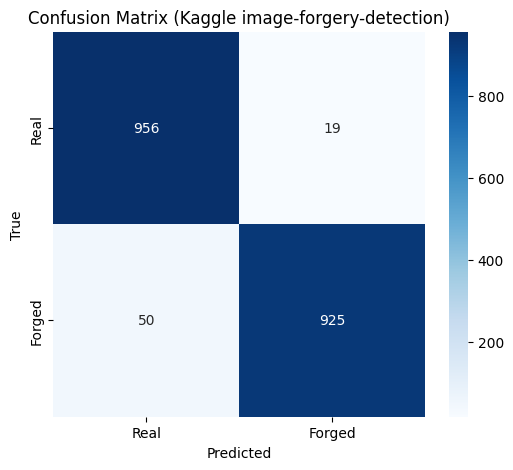

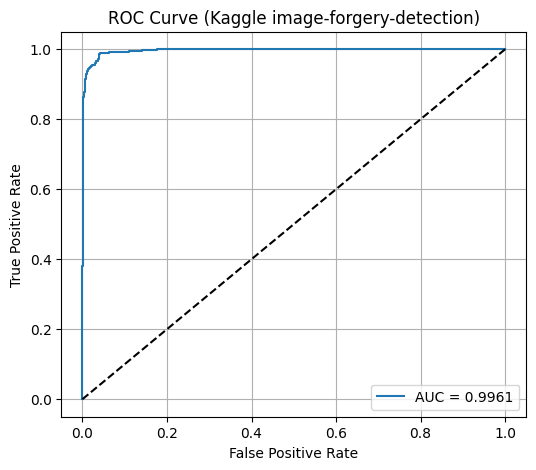

In [ ]:
# ============================================================
# 9. LOAD BEST MODEL & EVALUATE (ACC + AUC)
# ============================================================

best_clf = MultiBranchEffB3(dct_dim=DCT_BINS).to(device)
best_clf.load_state_dict(torch.load(clf_model_path, map_location=device))
best_clf.eval()

print("=== Loaded Best Multi-Branch EffB3 + DCT (Kaggle) ===")

y_true, y_pred, y_scores = [], [], []

with torch.no_grad():
    for imgs, dcts, labels in tqdm(test_loader,
                                   desc="Testing on Kaggle image-forgery-detection"):
        imgs   = imgs.to(device)
        dcts   = dcts.to(device)
        labels = labels.to(device)

        outputs = best_clf(imgs, dcts)
        probs = F.softmax(outputs, dim=1)

        _, predicted = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_scores.extend(probs[:, 1].cpu().numpy())  # prob of Forged

print("✅ Classification Report (Kaggle Forgery Test Set):")
print(classification_report(y_true, y_pred, target_names=["Real", "Forged"]))

acc = accuracy_score(y_true, y_pred)
print(f"Overall Test Accuracy: {acc:.4f}")

# AUC
try:
    auc = roc_auc_score(y_true, y_scores)
    print(f"ROC AUC (Test Set): {auc:.4f}")
except ValueError as e:
    print("AUC could not be computed:", e)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real","Forged"],
            yticklabels=["Real","Forged"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Kaggle image-forgery-detection)")
plt.show()

# ROC Curve
if 'auc' in locals():
    fpr, tpr, thr = roc_curve(y_true, y_scores)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Kaggle image-forgery-detection)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
# ============================================================
# 10. GRAD-CAM FOR MultiBranchEffB3 (EfficientNet-B3 + DCT)
# ============================================================

from PIL import Image
import random  # for sampling random test images

class GradCAM:
    def __init__(self, model, target_layer):
        """
        model        : full classifier (e.g., best_clf)
        target_layer : last conv layer of EfficientNet-B3 backbone
        """
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        # Forward hook: store activations
        def forward_hook(module, input, output):
            self.activations = output.detach()

        # Backward hook: store gradients wrt activations
        def backward_hook(module, grad_input, grad_output):
            # grad_output[0] is dL/dA
            self.gradients = grad_output[0].detach()

        self.fwd_handle = self.target_layer.register_forward_hook(forward_hook)
        self.bwd_handle = self.target_layer.register_full_backward_hook(backward_hook)

    def __del__(self):
        # Try to clean hooks when object is destroyed
        try:
            self.fwd_handle.remove()
            self.bwd_handle.remove()
        except:
            pass

    def generate_cam(self, x_img, x_dct, target_class=None):
        """
        x_img : (1, 3, H, W) image tensor (normalized, same as eval_transform)
        x_dct : (1, DCT_BINS) DCT feature tensor
        target_class : optional int (0=Real, 1=Forged);
                       if None, uses predicted class.

        Returns:
            cam        : (h, w) numpy array in [0, 1] (feature map size, not original size)
            pred_class : int
        """
        self.model.eval()
        self.model.zero_grad()

        with torch.enable_grad():
            outputs = self.model(x_img, x_dct)  # [1,2]

            if outputs.ndim == 1:
                outputs = outputs.unsqueeze(0)

            if target_class is None:
                target_class = outputs.argmax(dim=1).item()

            score = outputs[:, target_class]
            score.backward(retain_graph=True)

        # Get stored activations & gradients
        grads = self.gradients          # [1, C, h, w]
        acts  = self.activations        # [1, C, h, w]

        # Global-average pool gradients -> channel weights
        weights = grads.mean(dim=(2, 3), keepdim=True)   # [1, C, 1, 1]

        # Weighted sum of activations
        cam = (weights * acts).sum(dim=1, keepdim=False)  # [1, h, w]
        cam = cam.squeeze(0)  # [h, w]

        # ReLU + normalize to [0,1]
        cam = F.relu(cam)
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = torch.zeros_like(cam)

        return cam.cpu().numpy(), target_class


# ---- 10.1: Pick target layer from your model ----
# EfficientNet-B3 backbone lives in best_clf.backbone
# Its last conv block is backbone.features[-1]
target_layer = best_clf.backbone.features[-1]
gradcam = GradCAM(best_clf, target_layer)
print("✅ Grad-CAM is ready (target layer: backbone.features[-1])")


# ---- 10.2: Helper to get DCT tensor for a single image ----
def get_dct_tensor_for_image(img_path):
    """
    Uses your existing compute_dct_histogram to get a (1, DCT_BINS) tensor.
    """
    hist = compute_dct_histogram(img_path, num_bins=DCT_BINS)  # [DCT_BINS]
    dct_tensor = torch.from_numpy(hist).unsqueeze(0).to(device)  # [1, DCT_BINS]
    return dct_tensor


# ---- 10.3: Visualization function (GT + Pred, NO file names) ----
class_names = ("Real", "Forged")

def show_gradcam_for_image_with_gt(img_path,
                                   gt_label,
                                   model,
                                   gradcam,
                                   class_names=("Real", "Forged")):
    """
    Shows:
    - Original image
    - Grad-CAM heatmap
    - Grad-CAM overlay
    - Ground Truth and Predicted labels in titles
    (no file names)
    """

    # 1) Load original image
    orig_bgr = cv2.imread(img_path)
    if orig_bgr is None:
        raise ValueError("Could not read image")
    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    H, W, _ = orig_rgb.shape

    # 2) Preprocess image (same as classifier input)
    img_tensor = eval_transform(orig_rgb)           # [3, CLS_IMG_SIZE, CLS_IMG_SIZE]
    img_tensor = img_tensor.unsqueeze(0).to(device) # [1, 3, H, W]

    # 3) Compute DCT features
    dct_tensor = get_dct_tensor_for_image(img_path) # [1, DCT_BINS]

    # 4) Generate Grad-CAM
    cam, pred_class = gradcam.generate_cam(img_tensor, dct_tensor)

    # 5) Resize CAM to original image size
    cam_resized = cv2.resize(cam, (W, H))
    heatmap = (cam_resized * 255).astype(np.uint8)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # 6) Overlay heatmap on original image
    overlay_bgr = cv2.addWeighted(heatmap, 0.5, orig_bgr, 0.5, 0)
    overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

    gt_name   = class_names[gt_label]
    pred_name = class_names[pred_class]

    # 7) Plot results
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(orig_rgb)
    plt.title(f"Original (GT: {gt_name})")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay_rgb)
    plt.title(f"Overlay (Pred: {pred_name})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ---- 10.4: Show Grad-CAM for 5 random test images ----
random_indices = random.sample(range(len(test_imgs)), 5)

for idx in random_indices:
    img_path = test_imgs[idx]
    gt_label = test_labels[idx]   # 0 = Real, 1 = Forged
    show_gradcam_for_image_with_gt(
        img_path,
        gt_label,
        best_clf,
        gradcam,
        class_names=class_names
    )


Output hidden; open in https://colab.research.google.com to view.